In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dhrubangtalukdar/telco-customer-churn-data/synthetic_customer_churn_100k.csv


=== نظرة أولية على أول 5 صفوف ===


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No



حجم البيانات: 100000 صف و 9 عمود.

=== معلومات عن الأعمدة وأنواعها ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB

=== القيم المفقودة في كل عمود ===
CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

=== توزيع فئة التسرب (

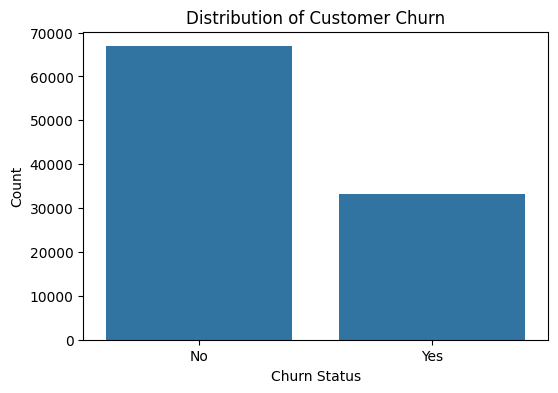

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تحديد مسار ملف البيانات
file_path = '/kaggle/input/datasets/dhrubangtalukdar/telco-customer-churn-data/synthetic_customer_churn_100k.csv'

# 1. قراءة الملف باستخدام Pandas
df = pd.read_csv(file_path)

# 2. عرض أول 5 صفوف للتعرف على شكل البيانات والأعمدة
print("=== نظرة أولية على أول 5 صفوف ===")
display(df.head())

# 3. معرفة حجم البيانات (عدد الصفوف والأعمدة)
print(f"\nحجم البيانات: {df.shape[0]} صف و {df.shape[1]} عمود.")

# 4. التحقق من أنواع البيانات والأعمدة (Data Types)
print("\n=== معلومات عن الأعمدة وأنواعها ===")
df.info()

# 5. الفحص السريع للقيم المفقودة (Missing Values)
print("\n=== القيم المفقودة في كل عمود ===")
print(df.isnull().sum())

# 6. التحقق من نسبة التوازن في عمود الهدف (Churn)
print("\n=== توزيع فئة التسرب (Target Variable) ===")
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
for idx, val in churn_counts.items():
    print(f"الفئة [{idx}]: {val} عميل ({churn_percentage[idx]:.2f}%)")

# رسم بياني لتوزيع Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. حذف عمود المعرف الفريد الذي لا يفيد النموذج
df_cleaned = df.drop(columns=['CustomerID'])

# 2. تحويل عمود الهدف Churn إلى قيم رقمية (0 و 1)
df_cleaned['Churn'] = df_cleaned['Churn'].map({'Yes': 1, 'No': 0})

# 3. تحويل الأعمدة النصية الأخرى باستخدام One-Hot Encoding
# سيقوم هذا تلقائياً بتحويل Gender, Contract, PaymentMethod إلى أعمدة ثنائية
df_encoded = pd.get_dummies(df_cleaned, columns=['Gender', 'Contract', 'PaymentMethod'], drop_first=True)

# عرض شكل البيانات الجديد والأعمدة بعد التحويل
print("=== شكل البيانات بعد التجهيز و One-Hot Encoding ===")
print(f"الحجم الجديد: {df_encoded.shape[0]} صف و {df_encoded.shape[1]} عمود.")
display(df_encoded.head())

# 4. فصل المتغيرات المستقلة (Features) عن المتغير التابع (Target)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 5. تقسيم البيانات إلى 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n=== حجم مجموعات البيانات بعد التقسيم ===")
print(f"مجموعة التدريب (X_train): {X_train.shape}")
print(f"مجموعة الاختبار (X_test): {X_test.shape}")

=== شكل البيانات بعد التجهيز و One-Hot Encoding ===
الحجم الجديد: 100000 صف و 12 عمود.


,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,56,68,147.58,10052.03,0,False,False,False,True,False,False,False
1,69,32,22.54,686.78,0,True,False,False,False,False,False,True
2,46,10,52.47,537.88,0,False,False,True,False,False,True,False
3,32,22,109.67,2390.04,1,True,False,False,False,False,False,True
4,60,54,130.98,7081.28,0,False,False,False,False,True,False,False



=== حجم مجموعات البيانات بعد التقسيم ===
مجموعة التدريب (X_train): (80000, 11)
مجموعة الاختبار (X_test): (20000, 11)


=== تقرير أداء الانحدار اللوجستي (Logistic Regression) ===
              precision    recall  f1-score   support

           0       0.76      0.85      0.80     13371
           1       0.61      0.47      0.53      6629

    accuracy                           0.72     20000
   macro avg       0.69      0.66      0.67     20000
weighted avg       0.71      0.72      0.71     20000


=== تقرير أداء الغابة العشوائية (Random Forest) ===
              precision    recall  f1-score   support

           0       0.77      0.85      0.81     13371
           1       0.62      0.49      0.55      6629

    accuracy                           0.73     20000
   macro avg       0.69      0.67      0.68     20000
weighted avg       0.72      0.73      0.72     20000



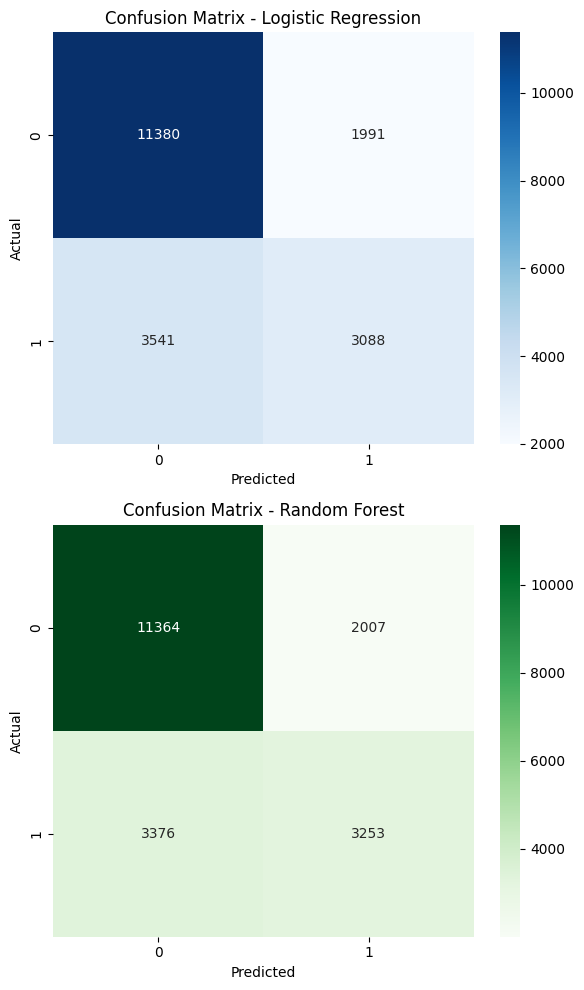

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. تدريب نموذج خط الأساس (Logistic Regression)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. تدريب نموذج متقدم (Random Forest) مع موازنة الفئات تلقائياً لحساب الـ 33%
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 3. طباعة تقارير الأداء للمقارنة بين النموذج الرقمي والمتقدم
print("=== تقرير أداء الانحدار اللوجستي (Logistic Regression) ===")
print(classification_report(y_test, lr_preds))

print("\n=== تقرير أداء الغابة العشوائية (Random Forest) ===")
print(classification_report(y_test, rf_preds))

# 4. رسم مصفوفة الإرباك (Confusion Matrix) للنموذجين عمودياً
fig, ax = plt.subplots(2, 1, figsize=(6, 10))

sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Logistic Regression')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix - Random Forest')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

=== تقرير أداء Random Forest بعتبة معدلة (0.3) ===
              precision    recall  f1-score   support

           0       0.85      0.62      0.71     13371
           1       0.50      0.77      0.61      6629

    accuracy                           0.67     20000
   macro avg       0.67      0.70      0.66     20000
weighted avg       0.73      0.67      0.68     20000



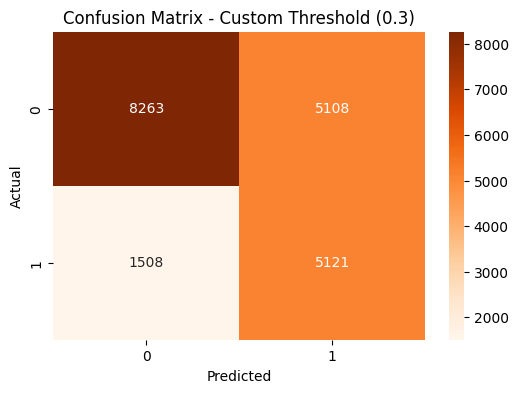

In [5]:
import numpy as np

# 1. الحصول على احتمالات التسرب (بدلاً من التوقع النهائي 0 أو 1)
# العمود رقم 1 يمثل احتمالية أن يكون العميل من الفئة 1 (Churn)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 2. تحديد عتبة تصنيف جديدة (مثلاً 30% بدلاً من 50%)
custom_threshold = 0.30

# 3. تطبيق العتبة الجديدة: إذا كان الاحتمال أكبر من 0.3، اعتبره 1، وإلا 0
custom_preds = (rf_probs >= custom_threshold).astype(int)

# 4. طباعة التقرير الجديد لمشاهدة التطور في مقياس Recall
print(f"=== تقرير أداء Random Forest بعتبة معدلة ({custom_threshold}) ===")
print(classification_report(y_test, custom_preds))

# 5. رسم مصفوفة الإرباك الجديدة لمشاهدة الانخفاض في الـ False Negatives
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, custom_preds), annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - Custom Threshold ({custom_threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/tmp/ipykernel_58/1166390448.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


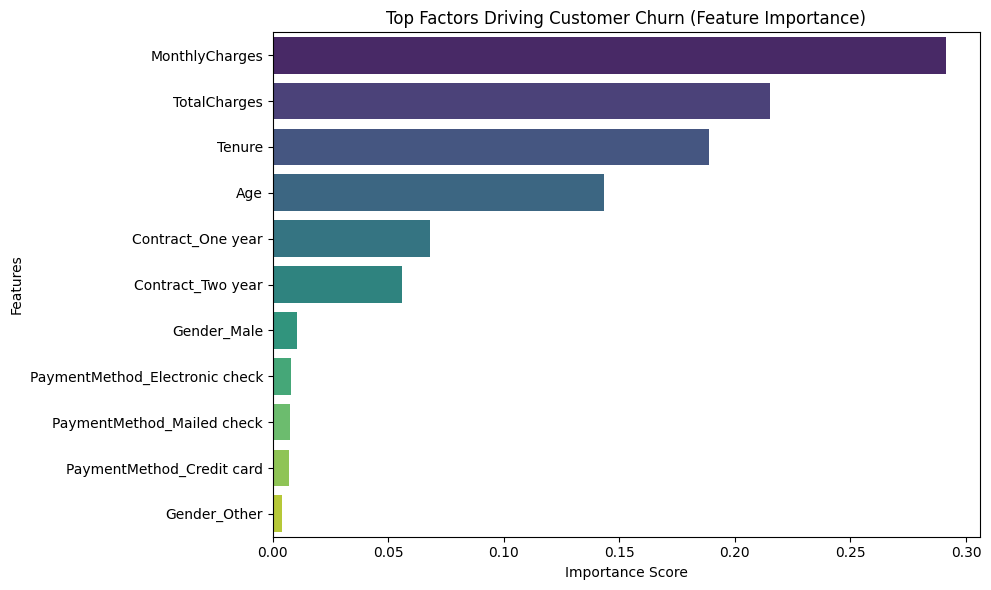

=== أهم 3 عوامل تؤثر على تسرب العملاء ===
          Feature  Importance
2  MonthlyCharges    0.291317
3    TotalCharges    0.215174
1          Tenure    0.188852


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. استخراج قيم الأهمية من نموذج Random Forest
importances = rf_model.feature_importances_

# 2. ربط القيم بأسماء الأعمدة (الميزات)
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. ترتيب الميزات تنازلياً من الأهم إلى الأقل أهمية
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. رسم النتائج لتوضيحها بصرياً
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Factors Driving Customer Churn (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# طباعة أعلى 3 عوامل
print("=== أهم 3 عوامل تؤثر على تسرب العملاء ===")
print(feature_importance_df.head(3))

In [9]:
import joblib

# نفترض أن اسم النموذج الذي دربته هو rf_model
# هذا الكود سيقوم بحفظ النموذج في ملف باسم 'churn_model.pkl'
joblib.dump(rf_model, 'churn_model.pkl')

print("تم حفظ النموذج بنجاح!")

تم حفظ النموذج بنجاح!
